# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API



## Customer Churn Prediction using Telco Churn Dataset

**Objective:** Build a reusable and production-ready machine learning pipeline for predicting customer churn using Scikit-learn Pipeline API.

## 1. Problem Statement

Customer churn refers to customers leaving a company or discontinuing a service. For telecom companies, identifying customers who are likely to churn is important because retaining existing customers is usually more cost-effective than acquiring new ones.

The purpose of this project is to build an end-to-end machine learning pipeline that predicts whether a customer is likely to churn based on demographic, account, and service-related features.

## 2. Import Libraries

We import libraries for data handling, visualization, preprocessing, model training, hyperparameter tuning, evaluation, and model export.

In [41]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score

)

# Model export
import joblib

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 3. Load Dataset


In [42]:
# Load dataset
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

# Display first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Explanation**

In this dataset:

*   **Features** (also known as independent variables or predictors) are all the columns in the dataset except 'Churn'. These include customer demographic information (e.g., `gender`, `SeniorCitizen`, `Partner`, `Dependents`), account information (e.g., `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`), and service information (e.g., `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`). These are the input variables used to make predictions.

*   **Target** (also known as the dependent variable or outcome variable) is the 'Churn' column. This column indicates whether a customer has left the company ('Yes') or not ('No'). This is the variable our machine learning model will try to predict.

## 4. Data Inspection

Before building the model, we inspect the dataset structure, missing values, duplicate records, and target variable distribution.

In [43]:
# Dataset shape
print('Dataset shape:', df.shape)

# Dataset information
df.info()

Dataset shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [44]:
# Check missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


In [45]:
# Check duplicate rows
print('Duplicate rows:', df.duplicated().sum())

# Target variable distribution
print(df['Churn'].value_counts())
print('Percentage distribution:')
print(df['Churn'].value_counts(normalize=True) * 100)

Duplicate rows: 0
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Percentage distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 5. Data Cleaning

The `TotalCharges` column is stored as an object because it contains blank values. We convert it to numeric and handle missing values later inside the preprocessing pipeline.

The `customerID` column is removed because it is only an identifier and does not help the model learn churn patterns.

In [46]:
# Convert TotalCharges to numeric
# Blank or invalid values will become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop customerID because it is not useful for prediction
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# Confirm data types after cleaning
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


## 6. Exploratory Data Analysis

We create a few simple visualizations to understand churn distribution and relationships between important variables.

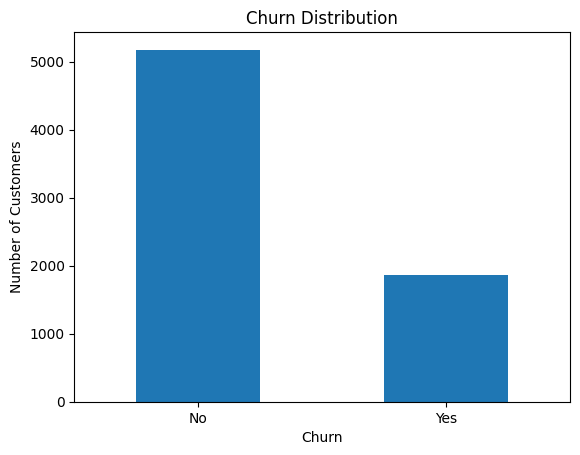

In [47]:
# Churn distribution visualization
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

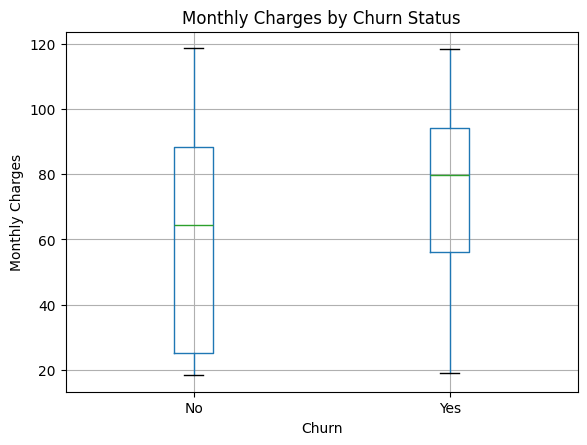

In [48]:
# Monthly charges by churn status
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('Monthly Charges by Churn Status')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

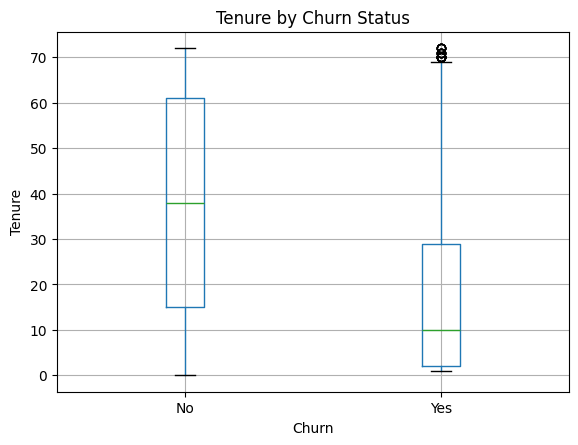

In [49]:
# Tenure by churn status
df.boxplot(column='tenure', by='Churn')
plt.title('Tenure by Churn Status')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

## 7. Feature and Target Split

In [50]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

print('Feature shape:', X.shape)
print('Target shape:', y.shape)

Feature shape: (7043, 19)
Target shape: (7043,)


## 8. Train-Test Split

We split the data into training and testing sets. Stratification is used to maintain the same churn ratio in both sets.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Testing set:', X_test.shape)

Training set: (5634, 19)
Testing set: (1409, 19)


## 9. Preprocessing Pipeline

We separate numerical and categorical columns.

For numerical columns:

- Missing values are filled with median
- Values are scaled using StandardScaler

For categorical columns:

- Missing values are filled with the most frequent value
- Categories are encoded using OneHotEncoder

This preprocessing is wrapped inside `ColumnTransformer`, which allows us to process different column types properly inside one pipeline.

In [52]:
# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [53]:
# Numerical preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## 10. Model Pipelines

We create complete machine learning pipelines for:

1. Logistic Regression
2. Random Forest Classifier

Each pipeline contains preprocessing and model training steps.

In [54]:
# Logistic Regression pipeline
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

## 11. Hyperparameter Tuning with GridSearchCV

GridSearchCV is used to test multiple hyperparameter combinations and select the best model based on ROC-AUC score.

ROC-AUC is useful here because churn is a classification problem and the dataset is somewhat imbalanced.

In [55]:
# Logistic Regression parameter grid
log_reg_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear']
}

# Random Forest parameter grid
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

## 12. Model Training

* **Logistic Regression**

In [56]:
# GridSearchCV for Logistic Regression
log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Train Logistic Regression
log_reg_grid.fit(X_train, y_train)

print('Best Logistic Regression Parameters:', log_reg_grid.best_params_)
print('Best Logistic Regression CV ROC-AUC:', log_reg_grid.best_score_)

Best Logistic Regression Parameters: {'model__C': 10, 'model__solver': 'liblinear'}
Best Logistic Regression CV ROC-AUC: 0.8458816402165059


* **Random Forest**

In [57]:
# GridSearchCV for Random Forest
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Train Random Forest
rf_grid.fit(X_train, y_train)

print('Best Random Forest Parameters:', rf_grid.best_params_)
print('Best Random Forest CV ROC-AUC:', rf_grid.best_score_)

Best Random Forest Parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best Random Forest CV ROC-AUC: 0.843743376909923


## 13. Model Evaluation Function

We define a reusable function to evaluate model performance using key classification metrics.

For churn prediction, **recall** is very important because missing a customer who is likely to churn can be costly for the business.

In [58]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a trained classification model."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

    print(f'{model_name} Classification Report')
    print('-' * 50)
    print(classification_report(y_test, y_pred))

    return results

In [59]:
# Evaluate both models
log_reg_results = evaluate_model(log_reg_grid.best_estimator_, X_test, y_test, 'Logistic Regression')
rf_results = evaluate_model(rf_grid.best_estimator_, X_test, y_test, 'Random Forest')

# Compare results
results_df = pd.DataFrame([log_reg_results, rf_results])
results_df

Logistic Regression Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Random Forest Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



,Model,Accuracy,Precision,F1 Score,ROC-AUC
0,Logistic Regression,0.804826,0.655172,0.603175,0.841130
1,Random Forest,0.799858,0.656463,0.577844,0.838545


**Explanation:**

**1. Classification Reports:**

These reports provide a detailed breakdown of performance metrics for each class (Churn: 0 for No and 1 for Yes):

- **Precision:** The proportion of positive identifications that were actually correct. For churn, it means out of all customers predicted to churn, how many actually churned.
- **Recall:** The proportion of actual positives that were identified correctly. For churn, it means out of all customers who actually churned, how many were correctly predicted.
- **F1-Score:** The harmonic mean of precision and recall. It's a useful metric when you want to seek a balance between precision and recall.
- **Support:** The number of actual occurrences of the class in the specified dataset (test set).
- **Accuracy:** The overall proportion of correctly classified instances.
- **Macro Avg & Weighted Avg:** These provide aggregated metrics across classes. 'Macro avg' computes metrics for each label and finds their unweighted mean. 'Weighted avg' accounts for class imbalance by weighting the scores by the number of true instances for each label.

**2. Results DataFrame (`results_df`):**

This DataFrame summarizes the key performance metrics (Accuracy, Precision, F1 Score, ROC-AUC) for both models, making it easy to compare them side-by-side. The ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) is particularly important for imbalanced datasets like churn, as it indicates the model's ability to distinguish between the positive and negative classes across all possible classification thresholds.

## 14. Select Best Model

The best model is selected based on ROC-AUC score. Depending on business needs, recall can also be prioritized because it helps identify more customers likely to churn.

In [60]:
# Select the model with the highest ROC-AUC score
if log_reg_results['ROC-AUC'] >= rf_results['ROC-AUC']:
    best_model = log_reg_grid.best_estimator_
    best_model_name = 'Logistic Regression'
else:
    best_model = rf_grid.best_estimator_
    best_model_name = 'Random Forest'

print('Selected Best Model:', best_model_name)

Selected Best Model: Logistic Regression


Based on the comparison of the ROC-AUC scores, the **Logistic Regression** model was selected as the best model. This decision is made because Logistic Regression showed a slightly higher **ROC-AUC score (0.8411)** compared to Random Forest (0.8385), indicating its superior overall discriminatory power between churning and non-churning customers in this particular evaluation.

## 15. Confusion Matrix

The confusion matrix shows correct and incorrect predictions for both churn and non-churn customers.

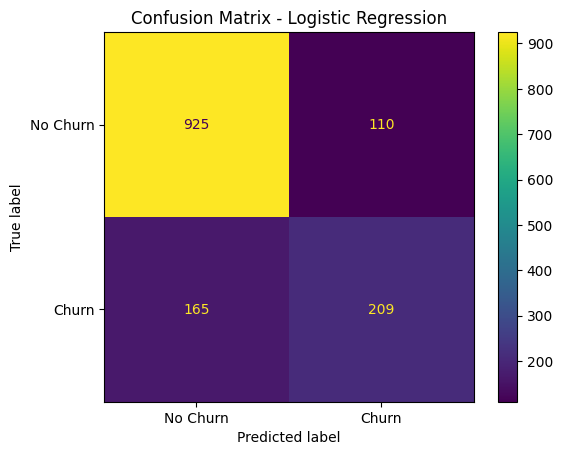

In [61]:
# Confusion matrix for best model
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn']).plot()
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

**Explanation:**

The confusion matrix provides a detailed look at how well our `Logistic Regression` model performed by categorizing its predictions into four types:

-   **True Negatives (TN): `925`**
    -   These are the customers who **did not churn** (actual `No`) and were **correctly predicted as not churning** (predicted `No`). This is a good outcome.

-   **False Positives (FP): `110`**
    -   These are the customers who **did not churn** (actual `No`) but were **incorrectly predicted as churning** (predicted `Yes`). This is a Type I error. In a business context, this means we might offer retention incentives to customers who would have stayed anyway.

-   **False Negatives (FN): `165`**
    -   These are the customers who **did churn** (actual `Yes`) but were **incorrectly predicted as not churning** (predicted `No`). This is a Type II error. This is often a more costly mistake in churn prediction, as we fail to identify customers who are about to leave, losing the opportunity to intervene.

-   **True Positives (TP): `209`**
    -   These are the customers who **did churn** (actual `Yes`) and were **correctly predicted as churning** (predicted `Yes`). This is another good outcome, as these are the customers we can target with retention efforts.

In summary, the model correctly identified 925 non-churning customers and 209 churning customers. However, it also misclassified 110 non-churning customers as churners (False Positives) and missed 165 actual churners (False Negatives).

## 16. ROC Curve

The ROC curve shows how well the model separates churn and non-churn customers at different classification thresholds.

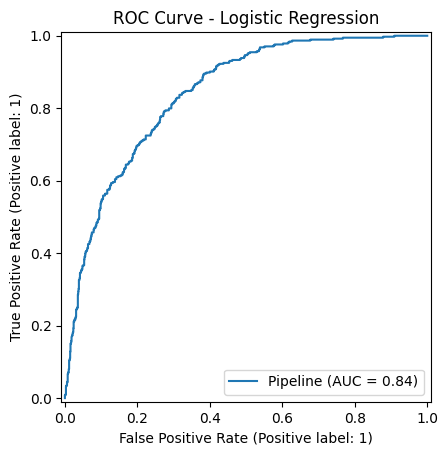

In [62]:
# ROC curve for best model
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f'ROC Curve - {best_model_name}')
plt.show()

The **Receiver Operating Characteristic (ROC) curve** is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various threshold settings.


An ROC AUC score of 0.84 is generally considered good. It indicates that the model has a strong ability to distinguish between the positive and negative classes. In a churn prediction context, it means the model is quite good at differentiating between customers who will churn and those who won't. An AUC of 1.0 would be a perfect model, while 0.5 would be no better than random chance. So, 0.84 is well above random and suggests a useful predictive model.

## 17. Export Final Pipeline - using Joblib

The final exported object includes both preprocessing and model steps. This means the saved pipeline can directly accept raw input data with the same structure as the original dataset.

In [63]:
# Save final pipeline
joblib.dump(best_model, 'telco_churn_pipeline.pkl')

print('Model pipeline exported successfully as telco_churn_pipeline.pkl')

Model pipeline exported successfully as telco_churn_pipeline.pkl


## 18. Test Loaded Pipeline

We reload the saved pipeline and test it on sample data to confirm that the exported model works correctly.

In [64]:
# Load saved pipeline
loaded_pipeline = joblib.load('telco_churn_pipeline.pkl')

# Test prediction using first five rows from test set
sample_predictions = loaded_pipeline.predict(X_test.head())
sample_probabilities = loaded_pipeline.predict_proba(X_test.head())[:, 1]

pd.DataFrame({
    'Predicted Churn': sample_predictions,
    'Churn Probability': sample_probabilities
})

,Predicted Churn,Churn Probability
0,0,0.047405
1,1,0.682594
2,0,0.050010
3,0,0.422637
4,0,0.022929


**Explanation:**

This confirms the saved model works correctly by predicting churn for a few sample customers. The output includes:

*   **`Predicted Churn`**: The model's binary decision (0 = No Churn, 1 = Churn).
*   **`Churn Probability`**: The likelihood (0-1) of a customer churning. Higher values mean higher churn risk.

For example, Customer 1 is predicted to churn (1) with a high probability (0.682), while Customer 0 is predicted not to churn (0) with a low probability (0.047).

## 18. Final Summary

In this project, an end-to-end machine learning pipeline was developed for customer churn prediction using the Telco Churn dataset.

For churn prediction, recall and F1-score are especially important because the business wants to correctly identify customers who are likely to leave. A reusable pipeline allows the model to be deployed or reused later without manually repeating preprocessing steps.

The Logistic Regression model was chosen over the Random Forest model primarily due to its slightly higher ROC-AUC score, indicating better overall discriminatory power for this dataset.

